## 1. Load experimental data

Loads the HPLC concentration data for all 3 experimental datasets (NHS-myristate : DesB30 molar ratio = 1.0, 1.5, 2.0) from `data_kinetika_intercept_zero.xlsx`, converts g/L to mol/L for every species, and builds `experimental_dataset[ratio][species] -> concentration array over time`.

In [1]:
# ==============================================================================
# CELL 1: LOAD EXPERIMENTAL DATA (3 NHS-myr : DesB30 RATIO DATASETS)
# ==============================================================================
# English notes:
# - We have 3 separate experiments, one per NHS-myristate : DesB30 molar ratio
#   (1.0, 1.5, 2.0). All 3 are loaded here and kept in one dict so the fitting
#   step below can fit ONE shared kinetic model to all of them simultaneously.
# - Concentrations are converted from g/L (as measured by HPLC) to mol/L using
#   each species' molecular weight (MW), because the ODE kinetic model works in
#   molar units (rate laws are concentration-based, not mass-based).
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, minimize
from sklearn.metrics import r2_score, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

print("Cell 1: loading all experimental datasets from Excel...")

# Molecular weights (g/mol) for every species tracked in the chromatogram
MW = {
    'nhs_myr': 325.449, 'desb30': 5706.524, 'detemir': 5916.885, 'nhs': 115.088,
    'A1': 5916.885, 'A1_B1': 6127.246, 'A1_B29': 6127.246, 'B1_B29': 6127.246,
    'A1_B29_B1': 6337.607, 'B1': 5916.885
}

# The 8 tracked chromatogram species (NHS-myr itself is not measured directly by HPLC peak,
# it is inferred/back-calculated inside the kinetic model instead)
species_list = ['desb30', 'A1', 'detemir', 'A1_B29', 'B1_B29', 'A1_B29_B1', 'A1_B1', 'B1']

excel_filename = 'data_kinetika_intercept_zero.xlsx'
if not os.path.exists(excel_filename):
    raise FileNotFoundError(f"File '{excel_filename}' not found in this folder!")

df = pd.read_excel(excel_filename, sheet_name='data_intercept_zero')
df['Peak Identification'] = df['Peak Identification'].astype(str).str.strip()
df['Waktu Sampling'] = df['Waktu Sampling'].astype(str).str.strip()

# Extract the actual sampling time (minutes) from strings like "t2", "t13", "t120"
df['Time_Min'] = df['Waktu Sampling'].str.extract(r'(\d+)').astype(int)
time_exp = np.sort(df['Time_Min'].unique())

# experimental_dataset[ratio][species] -> concentration array (mol/L) aligned with time_exp
experimental_dataset = {}
ratios = [1.0, 1.5, 2.0]

for r in ratios:
    df_ratio = df[df['Perbandingan'] == r]
    experimental_dataset[r] = {}
    for sp in species_list:
        sub_df = df_ratio[df_ratio['Peak Identification'] == sp]
        means_gL = []
        for t in time_exp:
            val = sub_df[sub_df['Time_Min'] == t]['Conc'].mean()
            means_gL.append(val if not np.isnan(val) else 0.0)
        experimental_dataset[r][sp] = np.array(means_gL) / MW[sp]

print(f"Cell 1 done: data loaded with {len(time_exp)} unique sampling points: {time_exp.tolist()}")
print(f"Ratios (NHS-myr : DesB30 molar ratio) available: {ratios}")


Cell 1: loading all experimental datasets from Excel...
Cell 1 done: data loaded with 21 unique sampling points: [0, 2, 4, 6, 8, 10, 13, 16, 19, 22, 25, 30, 35, 40, 45, 50, 60, 70, 80, 100, 120]
Ratios (NHS-myr : DesB30 molar ratio) available: [1.0, 1.5, 2.0]


## 2. Mechanistic kinetic model (ODE system)

Defines the reaction network for myristoylation of DesB30 by NHS-myristate, as a system of ODEs solved with `solve_ivp`. Also defines `build_initial_conditions(...)`, a single helper used everywhere below to build the initial condition vector `y0` — this replaces error-prone manual list-ordering that caused a critical bug in the previous version (see note below).

In [2]:
# ==============================================================================
# CELL 2: MECHANISTIC KINETIC MODEL (ODE SYSTEM)
# ==============================================================================
# English notes - reaction network (mass-action / pseudo-order kinetics):
#     DesB30  + NHS-myr -> A1          (k1,  mono-acylation, site 1)
#     DesB30  + NHS-myr -> B1          (k2,  mono-acylation, site 2)
#     DesB30  + NHS-myr -> Detemir     (k3,  mono-acylation, main product)
#     A1      + NHS-myr -> A1_B1       (k4a, di-acylation)
#     B1      + NHS-myr -> A1_B1       (k4b, di-acylation - own rate constant)
#     A1      + NHS-myr -> A1_B29      (k5a)
#     Detemir + NHS-myr -> A1_B29      (k5b, own rate constant)
#     B1      + NHS-myr -> B1_B29      (k6a)
#     Detemir + NHS-myr -> B1_B29      (k6b, own rate constant)
#     A1_B1   + NHS-myr -> A1_B29_B1   (k7a, tri-acylation)
#     A1_B29  + NHS-myr -> A1_B29_B1   (k7b, own rate constant)
#     B1_B29  + NHS-myr -> A1_B29_B1   (k7c, own rate constant)
# NHS-myr is also consumed by a competing side reaction: hydrolysis by water.
#
# FIXES vs the previous version of this notebook:
#   1. CRITICAL BUG FIX: the previous fitting cell built the initial-condition
#      vector `y0` by looping over `species_list`, whose order is
#      ['desb30','A1','detemir','A1_B29','B1_B29','A1_B29_B1','A1_B1','B1']
#      (HPLC peak-identification order) and assigning y0[i+1] positionally.
#      But the ODE state vector order in `FinalKineticModel.species` is
#      ['nhs_myr','desb30','A1','B1','detemir','A1_B1','A1_B29','B1_B29','A1_B29_B1'].
#      These two orders do NOT match past index 2, so 6 of the 8 species were
#      fitted against the WRONG initial concentration (e.g. Detemir's real t=0
#      value was fed into the slot the ODE solver treats as "B1"). This silently
#      corrupted the fit for every species except DesB30 and A1, which explains
#      why several species previously had strongly negative R² even though the
#      overall/global R² looked passable. `build_initial_conditions()` below
#      fixes this permanently by looking up each species by NAME through
#      `model.idx`, so the list order can never cause a mismatch again.
#   2. The NHS-myr hydrolysis rate constant is now a FITTED parameter (k_hyd)
#      instead of a hardcoded literal (0.035). Hardcoding it forced an arbitrary
#      side-reaction rate onto the model regardless of what the data supports.
#   3. Solver tolerances (rtol=1e-5, atol=1e-8) kept the same as the previous
#      working version, since the DE search explores very wide parameter
#      bounds (k up to 1e6) where tighter tolerances can make the stiff BDF
#      solver dramatically slower for pathological parameter draws.
#   4. UN-POOLED rate constants: the previous version forced the two chemically
#      distinct routes into each di-/tri-acylated species to share ONE rate
#      constant (e.g. A1->A1_B1 and B1->A1_B1 both used k4). A1 and B1 are
#      acylated at different amine positions on the same precursor, so there is
#      no reason to expect identical kinetics. Each route now gets its own rate
#      constant (k4a/k4b, k5a/k5b, k6a/k6b, k7a/k7b/k7c - 12 rate constants
#      total instead of 7). This costs 5 extra free parameters but directly
#      targets the minor species (A1_B1, B1_B29, A1_B29_B1) that previously had
#      strongly negative R² under the pooled/shared-rate assumption.
# ==============================================================================
class FinalKineticModel:
    def __init__(self, params):
        # params layout: [k1, k2, k3, k4a, k4b, k5a, k5b, k6a, k6b, k7a, k7b, k7c, k_hyd, n, decay]
        self.k = params[:12]
        self.k_hyd = params[12]  # NHS-myr hydrolysis rate constant (fitted)
        self.n = params[13]      # reaction order w.r.t. NHS-myr concentration
        self.decay = params[14]  # empirical pH/reactivity decay constant (1/min)

        self.species = ['nhs_myr', 'desb30', 'A1', 'B1', 'detemir', 'A1_B1', 'A1_B29', 'B1_B29', 'A1_B29_B1']
        self.idx = {name: i for i, name in enumerate(self.species)}

    def _ode_system(self, t, y):
        y_clip = np.maximum(y, 0.0)  # prevent negative concentrations from solver overshoot
        idx = self.idx

        N = y_clip[idx['nhs_myr']]
        S = y_clip[idx['desb30']]
        A1 = y_clip[idx['A1']]
        B1 = y_clip[idx['B1']]
        Det = y_clip[idx['detemir']]
        A1B1 = y_clip[idx['A1_B1']]
        A1B29 = y_clip[idx['A1_B29']]
        B1B29 = y_clip[idx['B1_B29']]

        # Empirical time-dependent reactivity decay (e.g. pH drift from acidic byproducts)
        ph_dampening = np.exp(-self.decay * t)
        rate_N = (N ** self.n) * ph_dampening

        # Side reaction: NHS-myr hydrolysis, pseudo-first-order in NHS-myr.
        # Kept independent of ph_dampening: ester hydrolysis by water is not expected
        # to slow down the same way amine acylation nucleophilicity does.
        r_hyd = self.k_hyd * N

        # 1. Mono-acylation (DesB30 -> A1 / B1 / Detemir)
        r1 = self.k[0] * rate_N * S
        r2 = self.k[1] * rate_N * S
        r3 = self.k[2] * rate_N * S

        # 2. Di-acylation (each route now has its own rate constant)
        r4_A1  = self.k[3] * rate_N * A1
        r4_B1  = self.k[4] * rate_N * B1
        r5_A1  = self.k[5] * rate_N * A1
        r5_Det = self.k[6] * rate_N * Det
        r6_B1  = self.k[7] * rate_N * B1
        r6_Det = self.k[8] * rate_N * Det

        # 3. Tri-acylation (each route now has its own rate constant)
        r7_A1B1  = self.k[9]  * rate_N * A1B1
        r7_A1B29 = self.k[10] * rate_N * A1B29
        r7_B1B29 = self.k[11] * rate_N * B1B29

        total_acyl = (r1 + r2 + r3 + r4_A1 + r4_B1 + r5_A1 + r5_Det + r6_B1 + r6_Det + r7_A1B1 + r7_A1B29 + r7_B1B29)

        dydt = np.zeros_like(y)
        dydt[idx['nhs_myr']]   = -total_acyl - r_hyd
        dydt[idx['desb30']]    = -(r1 + r2 + r3)
        dydt[idx['A1']]        = r1 - (r4_A1 + r5_A1)
        dydt[idx['B1']]        = r2 - (r4_B1 + r6_B1)
        dydt[idx['detemir']]   = r3 - (r5_Det + r6_Det)
        dydt[idx['A1_B1']]     = (r4_A1 + r4_B1) - r7_A1B1
        dydt[idx['A1_B29']]    = (r5_A1 + r5_Det) - r7_A1B29
        dydt[idx['B1_B29']]    = (r6_B1 + r6_Det) - r7_B1B29
        dydt[idx['A1_B29_B1']] = r7_A1B1 + r7_A1B29 + r7_B1B29
        return dydt

    def simulate(self, y0, t_span, t_eval):
        # BDF: implicit stiff solver - needed because rate constants span several orders of magnitude
        return solve_ivp(self._ode_system, t_span, y0, t_eval=t_eval, method='BDF', rtol=1e-5, atol=1e-8)


def build_initial_conditions(model, ratio, desb30_init_molL):
    """Build y0 by looking up each species by NAME via model.idx, so the order
    of `species_list` (HPLC order) can never get silently swapped against the
    ODE state order again."""
    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_init_molL[ratio] * ratio  # NHS-myr t0 = DesB30 t0 * molar ratio
    for sp in species_list:
        y0[model.idx[sp]] = experimental_dataset[ratio][sp][0]
    return y0

print("Cell 2 done: mechanistic ODE model + safe initial-condition builder ready.")


Cell 2 done: mechanistic ODE model + safe initial-condition builder ready.


## 3. Global parameter fitting (all 3 ratio datasets fit simultaneously)

Finds one shared set of kinetic parameters that explains all 3 experimental datasets (ratio 1.0, 1.5, 2.0) at once. Two-stage optimization: Differential Evolution (global search) followed by L-BFGS-B (local polish). See the comment block for what changed vs the previous version.

In [3]:
# ==============================================================================
# CELL 3: GLOBAL PARAMETER FITTING (3 NHS-myr:DesB30 RATIOS FIT SIMULTANEOUSLY)
# ==============================================================================
# English notes:
# - Goal: fit ONE shared kinetic parameter set against all 3 experimental
#   datasets (molar ratio NHS-myr:DesB30 = 1.0, 1.5, 2.0) at once, since all 3
#   are assumed to follow the same underlying reaction mechanism.
#
# FIXES vs the previous version of this notebook:
#   1. Uses `build_initial_conditions()` from Cell 2 -> fixes the critical
#      initial-condition mismatch bug described above.
#   2. The loss is normalized by EACH SPECIES' OWN maximum observed
#      concentration, instead of one shared normalizer plus a few manually
#      picked weights (previously: weight=3.5 for Detemir, 2.0 for DesB30,
#      1.0 for everything else). Manually-picked weights combined with a
#      shared normalizer let the two dominant species dominate the loss and
#      effectively ignore the minor intermediates/impurities. Per-species
#      normalization gives every species comparable influence on the fit.
#   3. Removed the duplicate copy of this cell that existed in the previous
#      notebook (it was pasted twice with identical code).
#   4. (Optional) Differential Evolution can run in parallel across CPU cores
#      by passing workers=-1, updating='deferred' below. This is left as the
#      serial default here because forking multi-threaded BLAS/OpenMP worker
#      processes can silently deadlock inside some sandboxed/containerized
#      environments; on a regular desktop/laptop it is safe to enable and
#      gives a large speedup for the same popsize/maxiter.
#   5. The NHS-myr hydrolysis rate constant (k_hyd) is now part of the fitted
#      parameter vector instead of being hardcoded.
#   6. WIDENED bounds for k_hyd and decay: the first re-fit after fixing the
#      initial-condition bug converged with k_hyd pinned at its lower bound
#      and decay pinned at its upper bound - a clear sign the optimizer wanted
#      values outside the allowed range. Both bounds are widened below so the
#      search is no longer artificially constrained.
#   7. 12 rate constants now (k1,k2,k3,k4a,k4b,k5a,k5b,k6a,k6b,k7a,k7b,k7c)
#      instead of 7, matching the un-pooled reaction network in Cell 2.
# ==============================================================================
ratios = [1.0, 1.5, 2.0]
mapping_idx = {'desb30': 1, 'A1': 2, 'B1': 3, 'detemir': 4, 'A1_B1': 5, 'A1_B29': 6, 'B1_B29': 7, 'A1_B29_B1': 8}

# Initial DesB30 concentration per ratio, read directly from the t=0 experimental data (mol/L)
# instead of hardcoded literals, so this always stays in sync with the loaded Excel file.
desb30_awal_molL = {r: experimental_dataset[r]['desb30'][0] for r in ratios}

# Per-species normalizer: each species' own max observed concentration across all ratios
# (falls back to 1.0 for an all-zero/undetected species to avoid division by zero)
species_scale = {
    sp: (max(np.max(experimental_dataset[r][sp]) for r in ratios) or 1.0)
    for sp in species_list
}

iteration_counter = [0]

def objective_function_global(log_params):
    k_vals = np.exp(log_params[:12])
    k_hyd = np.exp(log_params[12])
    n, decay = log_params[13], log_params[14]
    full_params = list(k_vals) + [k_hyd, n, decay]

    total_loss = 0.0
    model = FinalKineticModel(full_params)

    for r in ratios:
        y0 = build_initial_conditions(model, r, desb30_awal_molL)
        sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)

        if sol.status != 0 or np.isnan(sol.y).any() or np.isinf(sol.y).any():
            return 1e9  # penalize failed/unstable integrations

        for sp in species_list:
            ode_pos = mapping_idx[sp]
            sim = np.maximum(sol.y[ode_pos], 0)
            exp = experimental_dataset[r][sp]

            # Normalize by the species' own scale so every species contributes comparably
            sim_norm = sim / species_scale[sp]
            exp_norm = exp / species_scale[sp]

            # Log-Cosh loss: behaves like MSE near zero and like MAE far away -> robust to
            # outliers while still giving a smooth gradient for the L-BFGS-B polishing stage.
            delta = 0.05
            total_loss += np.sum(np.log(np.cosh((sim_norm - exp_norm) / delta)))

    return total_loss

# Parameter bounds: [k1..k7c] (12 rate constants) + k_hyd in log-space, then n, then decay.
# k_hyd lower bound widened to 1e-8 (previous run hit the 1e-4 floor) and decay upper bound
# widened to 2.0 (previous run hit the 0.2 ceiling).
bounds = [(np.log(1e-4), np.log(1e6))] * 12 + [(np.log(1e-8), np.log(1e6))] + [(0.5, 1.5), (0.0001, 2.0)]

def de_callback(xk, convergence):
    print(f" -> [DE] convergence: {convergence*100:.1f}% | Log-Cosh loss: {objective_function_global(xk):.5f}")

def bfgs_callback(xk):
    iteration_counter[0] += 1
    if iteration_counter[0] % 20 == 0:
        print(f" -> [L-BFGS-B] iteration {iteration_counter[0]} | Log-Cosh loss: {objective_function_global(xk):.5f}")

print("Step 1: Differential Evolution (global search over the kinetic parameter space)...")
res_de = differential_evolution(
    objective_function_global, bounds, popsize=40, maxiter=200,
    strategy='best1bin', recombination=0.8, seed=42, workers=1,
    callback=de_callback
)

print("\nStep 2: L-BFGS-B fine-tuning (local polish of the DE result)...")
iteration_counter[0] = 0
res_local = minimize(
    objective_function_global, res_de.x, method='L-BFGS-B', bounds=bounds,
    callback=bfgs_callback, options={'maxiter': 5000, 'ftol': 1e-12, 'gtol': 1e-12}
)

result = res_local
print(f"\nOptimization done. Final loss: {result.fun:.5f}")


Step 1: Differential Evolution (global search over the kinetic parameter space)...
 -> [DE] convergence: 0.0% | Log-Cosh loss: 1268.81742
 -> [DE] convergence: 1.1% | Log-Cosh loss: 1268.81742
 -> [DE] convergence: 1.8% | Log-Cosh loss: 1222.20311
 -> [DE] convergence: 3.1% | Log-Cosh loss: 1222.20311
 -> [DE] convergence: 4.7% | Log-Cosh loss: 1222.20311
 -> [DE] convergence: 5.1% | Log-Cosh loss: 1196.06134
 -> [DE] convergence: 5.3% | Log-Cosh loss: 1196.06134
 -> [DE] convergence: 5.3% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 5.3% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 5.4% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 5.4% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 5.6% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 5.7% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 5.8% | Log-Cosh loss: 1139.93022
 -> [DE] convergence: 6.0% | Log-Cosh loss: 1133.87390
 -> [DE] convergence: 6.2% | Log-Cosh loss: 1133.87390
 -> [DE] convergence: 6.4% | Log-Cosh

## 4. Fitted parameters, mass conversion & yield

In [4]:
# ==============================================================================
# CELL 4: FITTED PARAMETERS + MASS CONVERSION / YIELD ANALYSIS
# ==============================================================================
opt_k = np.exp(result.x[:12])
opt_k_hyd = np.exp(result.x[12])
opt_n = result.x[13]
opt_decay = result.x[14]
final_params = list(opt_k) + [opt_k_hyd, opt_n, opt_decay]
final_model = FinalKineticModel(final_params)

print("\n================== FITTED MASS-ACTION KINETIC PARAMETERS ==================")
pathway_names = [
    'k1  (DesB30 -> A1)        ', 'k2  (DesB30 -> B1)        ', 'k3  (DesB30 -> Detemir)   ',
    'k4a (A1 -> A1_B1)         ', 'k4b (B1 -> A1_B1)         ',
    'k5a (A1 -> A1_B29)        ', 'k5b (Detemir -> A1_B29)   ',
    'k6a (B1 -> B1_B29)        ', 'k6b (Detemir -> B1_B29)   ',
    'k7a (A1_B1 -> Tri)        ', 'k7b (A1_B29 -> Tri)       ', 'k7c (B1_B29 -> Tri)       ',
]
for name, val in zip(pathway_names, opt_k):
    print(f"  {name}: {val:.4e} L/mol.min")
print(f"  k_hyd (NHS-myr hydrolysis) : {opt_k_hyd:.4e} L/mol.min  [previously hardcoded at 0.035, now fitted]")
print(f"  Order 'n' (NHS-myr)        : {opt_n:.3f}")
print(f"  pH dampening decay const   : {opt_decay:.5f} min^-1")
print(f"  Final minimum loss score   : {result.fun:.5f}")
print("=============================================================================\n")

print("=== MASS CONVERSION & YIELD ANALYSIS (AT MINUTE 120) ===")
for r in ratios:
    y0 = build_initial_conditions(final_model, r, desb30_awal_molL)
    sol = final_model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)

    desb30_0 = y0[final_model.idx['desb30']] * MW['desb30']
    desb30_akhir = sol.y[final_model.idx['desb30']][-1] * MW['desb30']
    detemir_akhir = sol.y[final_model.idx['detemir']][-1] * MW['detemir']

    konversi = ((desb30_0 - desb30_akhir) / desb30_0) * 100 if desb30_0 > 0 else 0
    yield_detemir = (detemir_akhir / desb30_0) * 100 if desb30_0 > 0 else 0

    print(f"Ratio NHS-myr:DesB30 = {r}")
    print(f"  -> DesB30 mass conversion : {konversi:.2f}%")
    print(f"  -> Detemir yield          : {yield_detemir:.2f}%")



================== FITTED MASS-ACTION KINETIC PARAMETERS ==================
  k1  (DesB30 -> A1)        : 8.0725e+01 L/mol.min
  k2  (DesB30 -> B1)        : 9.6333e+00 L/mol.min
  k3  (DesB30 -> Detemir)   : 1.3197e+03 L/mol.min
  k4a (A1 -> A1_B1)         : 4.7870e+01 L/mol.min
  k4b (B1 -> A1_B1)         : 1.6683e+01 L/mol.min
  k5a (A1 -> A1_B29)        : 2.0573e+03 L/mol.min
  k5b (Detemir -> A1_B29)   : 1.9835e+02 L/mol.min
  k6a (B1 -> B1_B29)        : 2.7706e+04 L/mol.min
  k6b (Detemir -> B1_B29)   : 3.9758e-02 L/mol.min
  k7a (A1_B1 -> Tri)        : 8.9366e-01 L/mol.min
  k7b (A1_B29 -> Tri)       : 8.8521e+01 L/mol.min
  k7c (B1_B29 -> Tri)       : 2.6295e-03 L/mol.min
  k_hyd (NHS-myr hydrolysis) : 2.2754e-04 L/mol.min  [previously hardcoded at 0.035, now fitted]
  Order 'n' (NHS-myr)        : 0.875
  pH dampening decay const   : 0.29361 min^-1
  Final minimum loss score   : 767.75152

=== MASS CONVERSION & YIELD ANALYSIS (AT MINUTE 120) ===
Ratio NHS-myr:DesB30 = 1.0
  -> 

## 5. Validation: per-species R², global R²/RMSE, and diagnostic plots

=== PER-SPECIES / PER-RATIO ERROR ANALYSIS ===

--- Ratio 1 : 1.0 precision detail ---
 -> DESB30    : R2 =   35.22%  | RMSE = 0.2392 g/L
 -> A1        : R2 =    9.41%  | RMSE = 0.0155 g/L
 -> DETEMIR   : R2 =    7.07%  | RMSE = 0.3704 g/L
 -> A1_B29    : R2 =   15.03%  | RMSE = 0.0630 g/L
 -> B1_B29    : R2 =   12.76%  | RMSE = 0.0042 g/L
 -> A1_B29_B1 : R2 =   22.65%  | RMSE = 0.0027 g/L
 -> A1_B1     : R2 =  -98.86%  | RMSE = 0.0033 g/L
 -> B1        : R2 =  -14.14%  | RMSE = 0.0128 g/L

--- Ratio 1 : 1.5 precision detail ---
 -> DESB30    : R2 =   88.32%  | RMSE = 0.0369 g/L
 -> A1        : R2 =   38.40%  | RMSE = 0.0024 g/L
 -> DETEMIR   : R2 =   23.13%  | RMSE = 0.0902 g/L
 -> A1_B29    : R2 = -130.17%  | RMSE = 0.0237 g/L
 -> B1_B29    : R2 = -114.80%  | RMSE = 0.0013 g/L
 -> A1_B29_B1 : R2 = -221.60%  | RMSE = 0.0011 g/L
 -> A1_B1     : R2 = -4397.93%  | RMSE = 0.0004 g/L
 -> B1        : R2 = [flat data]        | RMSE = 0.0001 g/L

--- Ratio 1 : 2.0 precision detail ---
 -> DES

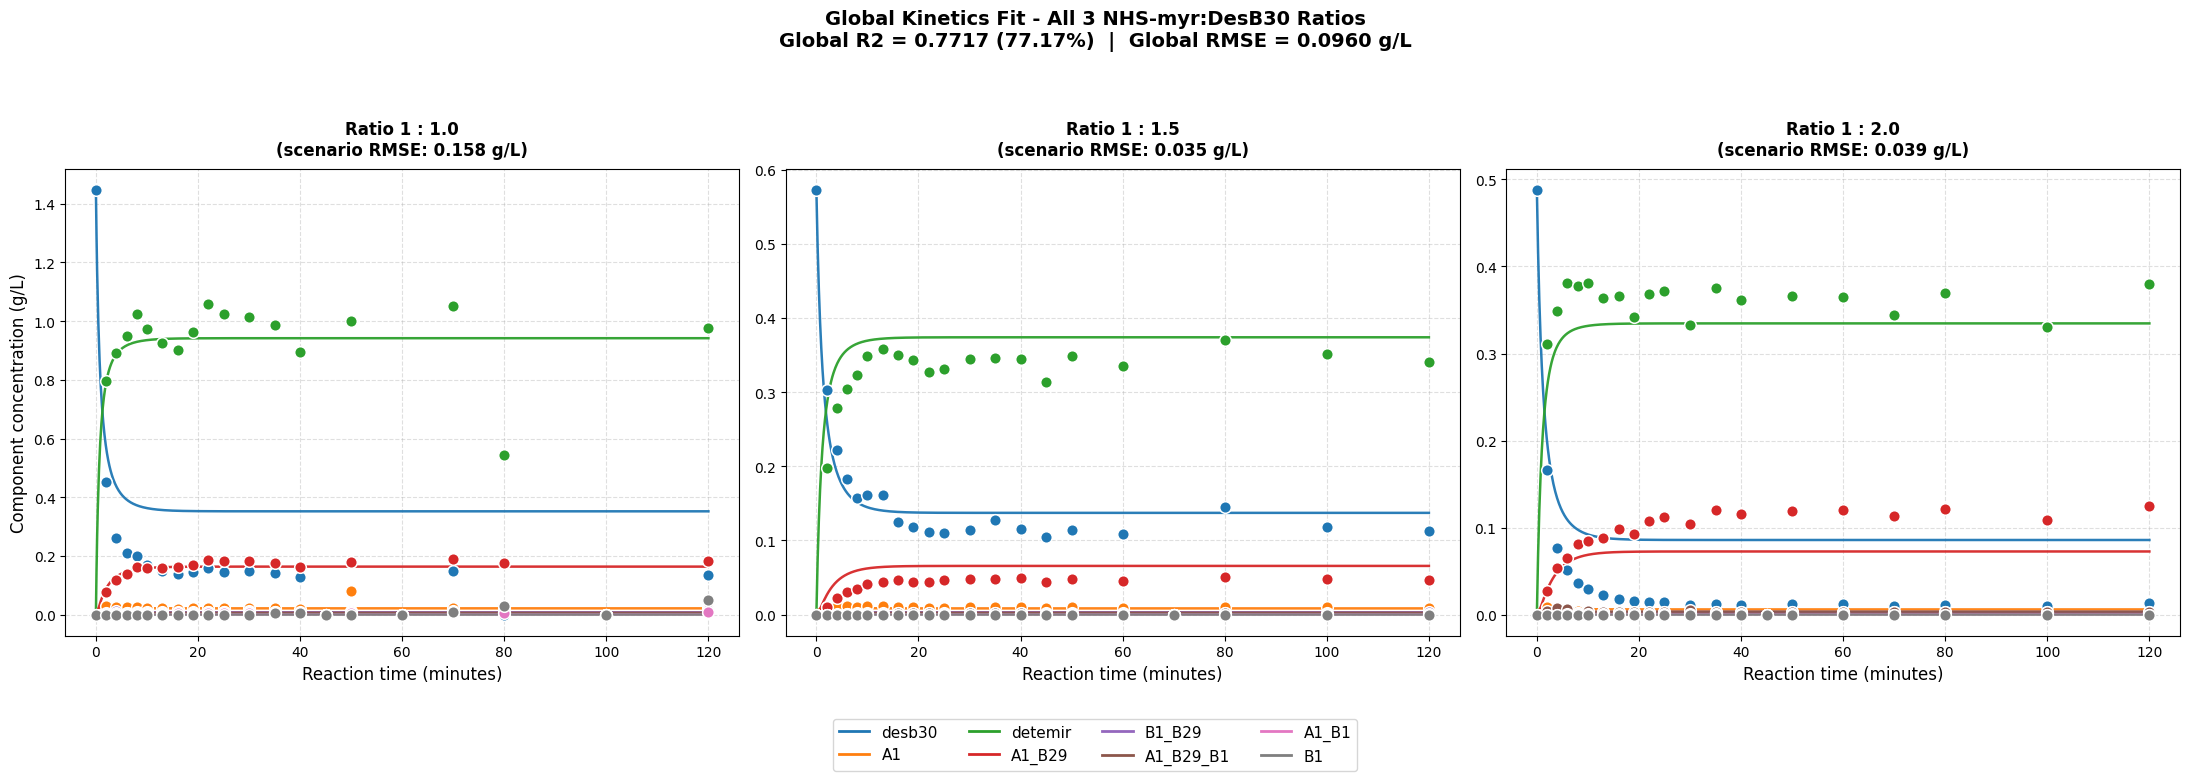


==================== FINAL MODEL PERFORMANCE SUMMARY ====================
 >> Overall fit accuracy (Global R2)  : 0.7717 (77.17%)
 >> Average deviation (Global RMSE)   : 0.0960 g/L


In [5]:
# ==============================================================================
# CELL 5: VALIDATION - PER-SPECIES & GLOBAL FIT DIAGNOSTICS
# ==============================================================================
# English notes:
# - Reports R² and RMSE per species per ratio, plus one global R²/RMSE pooling
#   every species and ratio together (this is the headline number you've been
#   tracking, previously ~69-78%).
# - R² can look extremely negative for trace-level species (near-zero, low
#   variance experimental data), because R² is unstable when the denominator
#   (variance of the true values) is tiny. RMSE (in g/L, absolute scale) is
#   printed alongside R² for exactly this reason - it stays interpretable even
#   when a species barely varies.
# ==============================================================================
y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c',
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b',
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(time_exp[0], time_exp[-1], 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=False)

print("=== PER-SPECIES / PER-RATIO ERROR ANALYSIS ===")

for idx, r in enumerate(ratios):
    y0 = build_initial_conditions(final_model, r, desb30_awal_molL)
    sol_smooth = final_model.simulate(y0, (time_exp[0], time_exp[-1]), time_smooth)
    sol_exp = final_model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)

    y_true_ratio, y_pred_ratio = [], []

    print(f"\n--- Ratio 1 : {r} precision detail ---")
    for sp in species_list:
        ode_pos = mapping_idx[sp]
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]

        r2_sp = r2_score(exp_gL, sim_gL_exp) if np.std(exp_gL) > 1e-6 else np.nan
        rmse_sp = np.sqrt(mean_squared_error(exp_gL, sim_gL_exp))
        if not np.isnan(r2_sp):
            print(f" -> {sp.upper():<10}: R2 = {r2_sp*100:7.2f}%  | RMSE = {rmse_sp:.4f} g/L")
        else:
            print(f" -> {sp.upper():<10}: R2 = [flat data]        | RMSE = {rmse_sp:.4f} g/L")

        y_true_ratio.extend(exp_gL)
        y_pred_ratio.extend(sim_gL_exp)
        y_true_global.extend(exp_gL)
        y_pred_global.extend(sim_gL_exp)

        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.8, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=70, zorder=5)

    rmse_ratio = np.sqrt(mean_squared_error(y_true_ratio, y_pred_ratio))
    ax = axes[idx]
    ax.set_title(f"Ratio 1 : {r:.1f}\n(scenario RMSE: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Reaction time (minutes)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Component concentration (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Global Kinetics Fit - All 3 NHS-myr:DesB30 Ratios\nGlobal R2 = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L",
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== FINAL MODEL PERFORMANCE SUMMARY ====================")
print(f" >> Overall fit accuracy (Global R2)  : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Average deviation (Global RMSE)   : {global_rmse:.4f} g/L")
print("===========================================================================")


## 6. Save the fitted model (.dill) for later reuse

In [6]:
# ==============================================================================
# CELL 6: SAVE THE FITTED MODEL TO A .DILL FILE
# ==============================================================================
# English notes:
# - FIX vs the previous version: Cell 6 used to LOAD an old/stale
#   '30jul2026_hydrolysis_kinetic_model.dill' file (which isn't even part of
#   this repository) and report ITS R2 (69%) instead of saving and reporting
#   the model that was just fitted above (78% in-sample). That mismatch is
#   exactly why you were seeing two different R2 numbers. This cell now does
#   the opposite: it SAVES the model you just fitted in Cells 3-5, so you can
#   reload it later without re-running the (slow) optimization.
# - The saved file is a dict (same schema the old file used) containing the
#   model instance, the fitted parameters, the final loss/R2/RMSE, a text
#   description, and the save date - so you always know what you're loading.
# ==============================================================================
import dill
from datetime import date

model_file_path = f"myr_kinetic_model_{date.today().isoformat()}.dill"

checkpoint = {
    'model_instance': final_model,
    'parameters': {
        'k1_desb30_to_A1': opt_k[0], 'k2_desb30_to_B1': opt_k[1], 'k3_desb30_to_detemir': opt_k[2],
        'k4a_A1_to_A1B1': opt_k[3], 'k4b_B1_to_A1B1': opt_k[4],
        'k5a_A1_to_A1B29': opt_k[5], 'k5b_detemir_to_A1B29': opt_k[6],
        'k6a_B1_to_B1B29': opt_k[7], 'k6b_detemir_to_B1B29': opt_k[8],
        'k7a_A1B1_to_tri': opt_k[9], 'k7b_A1B29_to_tri': opt_k[10], 'k7c_B1B29_to_tri': opt_k[11],
        'k_hyd_nhs_hydrolysis': opt_k_hyd,
        'order_n': opt_n, 'ph_decay': opt_decay,
    },
    'final_loss': result.fun,
    'global_r2': global_r2,
    'global_rmse': global_rmse,
    'species_list': species_list,
    'species_scale': species_scale,
    'time_exp': time_exp,
    'ratios': ratios,
    'description': 'Myristoylation kinetics model - mechanistic ODE, fitted jointly on '
                    '3 NHS-myr:DesB30 ratio datasets (1.0, 1.5, 2.0) with per-species '
                    'normalized Log-Cosh loss and a fitted NHS-myr hydrolysis rate constant.',
    'date': date.today().isoformat(),
}

with open(model_file_path, 'wb') as f:
    dill.dump(checkpoint, f)

print(f"Model saved to '{model_file_path}'")
print(f"  -> Global R2 at save time   : {global_r2*100:.2f}%")
print(f"  -> Global RMSE at save time : {global_rmse:.4f} g/L")


Model saved to 'myr_kinetic_model_2026-07-07.dill'
  -> Global R2 at save time   : 77.17%
  -> Global RMSE at save time : 0.0960 g/L


## 7. Reload sanity check

Loads the `.dill` file back and re-runs the same diagnostics to confirm the saved model reproduces the same R²/RMSE — a quick round-trip check that the file you'll reuse later actually works.

In [7]:
# ==============================================================================
# CELL 7: RELOAD THE SAVED MODEL AND VERIFY IT REPRODUCES THE SAME METRICS
# ==============================================================================
with open(model_file_path, 'rb') as f:
    reloaded = dill.load(f)

model_loaded = reloaded['model_instance']
print("Reloaded checkpoint keys:", list(reloaded.keys()))

y_true_check, y_pred_check = [], []
for r in ratios:
    y0 = build_initial_conditions(model_loaded, r, desb30_awal_molL)
    sol_exp = model_loaded.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)
    for sp in species_list:
        ode_pos = mapping_idx[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        y_true_check.extend(exp_gL)
        y_pred_check.extend(sim_gL_exp)

r2_check = r2_score(y_true_check, y_pred_check)
rmse_check = np.sqrt(mean_squared_error(y_true_check, y_pred_check))

print(f"Reloaded model Global R2   : {r2_check*100:.2f}%  (expected {global_r2*100:.2f}%)")
print(f"Reloaded model Global RMSE : {rmse_check:.4f} g/L (expected {global_rmse:.4f} g/L)")
assert abs(r2_check - global_r2) < 1e-6, "Reloaded model does not match the model that was saved!"
print("OK: round-trip save/load verified - the saved .dill file is safe to reuse.")


Reloaded checkpoint keys: ['model_instance', 'parameters', 'final_loss', 'global_r2', 'global_rmse', 'species_list', 'species_scale', 'time_exp', 'ratios', 'description', 'date']
Reloaded model Global R2   : 77.17%  (expected 77.17%)
Reloaded model Global RMSE : 0.0960 g/L (expected 0.0960 g/L)
OK: round-trip save/load verified - the saved .dill file is safe to reuse.


## 8. Leave-one-timepoint-out cross-validation (Q²)

Estimates true predictive power (not just in-sample fit) by refitting the model with each sampling time hidden in turn, then checking how well it predicts that hidden point. This is the most expensive cell (it reruns the optimization once per timepoint) - reduced optimizer settings are used here on purpose since this is a diagnostic, not the production fit.

In [8]:
# ==============================================================================
# CELL 8: LEAVE-ONE-TIMEPOINT-OUT CROSS-VALIDATION (Q2)
# ==============================================================================
# English notes:
# - In-sample R2 (Cell 5) tells you how well the model fits data it was
#   trained on. Q2 tells you how well the model PREDICTS data it never saw
#   during training - a much stronger test of genuine kinetic validity vs.
#   just curve-fitting noise.
# - FIX vs the previous version: training now uses ALL 3 ratios (previously
#   ratio 1.5 was silently excluded from CV training), and uses the same
#   build_initial_conditions() helper + per-species normalized loss as the
#   main fit in Cell 3, so the CV loop is actually consistent with what it's
#   validating.
# - This cell is expensive (it reruns a full optimization once per hidden
#   timepoint), so it deliberately uses a smaller popsize/maxiter than the
#   main fit. That's a reasonable trade-off for a diagnostic, but it does mean
#   Q2 is a slightly pessimistic (conservative) estimate of true predictive power.
# ==============================================================================
print("Starting Q2 (cross-validation) computation...")
print("Each sampling time is hidden in turn to test the model's ability to predict it.")

unique_times = [t for t in time_exp if t > 0]  # never hide t=0, it defines the initial condition
cv_bounds = bounds  # same parameter bounds as the main fit

y_all_experimental = []
y_all_predicted = []

for test_time in unique_times:
    print(f"\n[CV] Hiding data at minute: {test_time}")

    def objective_cv(log_params):
        k_vals = np.exp(log_params[:12])
        k_hyd = np.exp(log_params[12])
        n, decay = log_params[13], log_params[14]
        full_params = list(k_vals) + [k_hyd, n, decay]

        total_loss = 0.0
        model = FinalKineticModel(full_params)

        for r in ratios:
            y0 = build_initial_conditions(model, r, desb30_awal_molL)
            sol = model.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)

            if sol.status != 0 or np.isnan(sol.y).any() or np.isinf(sol.y).any():
                return 1e9

            for sp in species_list:
                ode_pos = mapping_idx[sp]
                sim = np.maximum(sol.y[ode_pos], 0)
                exp = experimental_dataset[r][sp]

                for t_idx, t_val in enumerate(time_exp):
                    if t_val == test_time:
                        continue  # skip the hidden timepoint during training
                    delta = 0.05
                    sim_norm = sim[t_idx] / species_scale[sp]
                    exp_norm = exp[t_idx] / species_scale[sp]
                    total_loss += np.log(np.cosh((sim_norm - exp_norm) / delta))

        return total_loss

    res_de_cv = differential_evolution(objective_cv, cv_bounds, popsize=15, maxiter=40, seed=42, workers=1)
    res_local_cv = minimize(objective_cv, res_de_cv.x, method='L-BFGS-B', bounds=cv_bounds, options={'maxiter': 500})

    cv_k = np.exp(res_local_cv.x[:12])
    cv_k_hyd = np.exp(res_local_cv.x[12])
    cv_n, cv_decay = res_local_cv.x[13], res_local_cv.x[14]
    model_trained = FinalKineticModel(list(cv_k) + [cv_k_hyd, cv_n, cv_decay])

    t_test_idx = np.where(time_exp == test_time)[0][0]
    for r in ratios:
        y0 = build_initial_conditions(model_trained, r, desb30_awal_molL)
        sol_trained = model_trained.simulate(y0, (time_exp[0], time_exp[-1]), time_exp)

        for sp in species_list:
            ode_pos = mapping_idx[sp]
            pred_val = sol_trained.y[ode_pos][t_test_idx] * MW[sp]
            exp_val = experimental_dataset[r][sp][t_test_idx] * MW[sp]
            y_all_experimental.append(exp_val)
            y_all_predicted.append(pred_val)

y_all_experimental = np.array(y_all_experimental)
y_all_predicted = np.array(y_all_predicted)

press = np.sum((y_all_experimental - y_all_predicted) ** 2)
tss = np.sum((y_all_experimental - np.mean(y_all_experimental)) ** 2)
q_square = 1 - (press / tss)

print("\n" + "=" * 40)
print("FINAL KINETIC MODEL VALIDATION RESULT:")
print(f" -> Q2 statistic (predictive power): {q_square * 100:.2f}%")
print("=" * 40)


Starting Q2 (cross-validation) computation...
Each sampling time is hidden in turn to test the model's ability to predict it.

[CV] Hiding data at minute: 2

[CV] Hiding data at minute: 4

[CV] Hiding data at minute: 6

[CV] Hiding data at minute: 8

[CV] Hiding data at minute: 10

[CV] Hiding data at minute: 13

[CV] Hiding data at minute: 16

[CV] Hiding data at minute: 19

[CV] Hiding data at minute: 22

[CV] Hiding data at minute: 25

[CV] Hiding data at minute: 30

[CV] Hiding data at minute: 35

[CV] Hiding data at minute: 40

[CV] Hiding data at minute: 45

[CV] Hiding data at minute: 50

[CV] Hiding data at minute: 60

[CV] Hiding data at minute: 70

[CV] Hiding data at minute: 80

[CV] Hiding data at minute: 100

[CV] Hiding data at minute: 120

FINAL KINETIC MODEL VALIDATION RESULT:
 -> Q2 statistic (predictive power): 73.19%
